In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("data/train.csv",encoding="utf-8")
test_df = pd.read_csv("data/test.csv",encoding="utf-8")

In [3]:
train_df.shape

(891, 12)

In [4]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
test_df.shape

(418, 11)

In [7]:
train_df["train_col"] = 1
test_df["train_col"] = 0

In [8]:
merged_df = pd.concat([train_df,test_df],axis=0)

In [9]:
merged_df.shape

(1309, 13)

In [10]:
merged_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
train_col         0
dtype: int64

In [11]:
get_name = merged_df["Name"].apply(lambda x: x.split(",")[1])
get_title = get_name.apply(lambda x: x.split(".")[0])
merged_df["Title"] = get_title

In [12]:
title_map = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mrs": "Mrs",
    "Mme": "Mrs",
    "Master": "Master",
    "Rev": "Rare",
    "Dr": "Rare",
    "Col": "Rare",
    "Major": "Rare",
    "Don": "Rare",
    "Dona": "Rare",
    "Lady": "Rare",
    "Sir": "Rare",
    "Capt": "Rare",
    "the Countess": "Rare",
    "Jonkheer": "Rare",
}

merged_df["Title"] = merged_df["Title"].str.strip().map(title_map)

In [13]:
merged_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0,Mr
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,Rare
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,Mr
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0,Mr


In [14]:
cabin_list = merged_df["Cabin"].astype(str).to_list()
cabin_list
cabins = []
for x in cabin_list:
    if str(x) == "nan":
        cabins.append("Unknown")
    else:
        cabins.append(x[0])

merged_df["Cabin_Title"] = cabins

In [15]:
merged_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title,Cabin_Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr,Unknown
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss,Unknown
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr,Unknown


In [16]:
age_df = merged_df.copy()

In [17]:
# age_df = age_df.drop(["Survived","Cabin"],axis=1)

In [18]:
age_df["Fare"] = age_df["Fare"].fillna(age_df["Fare"].median())
age_df["Embarked"] = age_df["Embarked"].fillna(age_df["Embarked"].mode()[0])

In [19]:
age_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
train_col         0
Title             0
Cabin_Title       0
dtype: int64

In [20]:
age_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title,Cabin_Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr,Unknown
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss,Unknown
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr,Unknown


In [21]:
age_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_col', 'Title',
       'Cabin_Title'],
      dtype='str')

In [22]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

encoders = {}
scalers  = {}

or_cols = ['Title', 'Embarked', 'Sex', 'Ticket', 'Cabin_Title']
for col in or_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    age_df[col] = enc.fit_transform(age_df[[col]])
    encoders[col] = enc                      

scale_cols = ["Fare", "SibSp", "Parch", "Age", "Pclass"]
sc = StandardScaler()
age_df[scale_cols] = sc.fit_transform(age_df[scale_cols])
scalers["standard"] = (sc, scale_cols)

In [23]:
def untransform(df):
    out = df.copy()
    s, cols = scalers["standard"]
    out[cols] = s.inverse_transform(out[cols])
    for col, enc in encoders.items():
        out[col] = enc.inverse_transform(out[[col]]).ravel()
    return out

In [24]:
age_con = age_df["Age"].isna()

age_na = age_df[age_con]
age_not_na = age_df[~age_con]

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iners = []
sil_scores = []

features = ["Pclass","Sex","SibSp","Parch","Embarked","Title"]
data = age_df[features]

r = range(2,40)
for i in r:
    model = KMeans(n_clusters=i)
    model.fit(data)
    iner = model.inertia_
    sil_score = silhouette_score(data, model.predict(data))
    sil_scores.append(sil_score)
    iners.append(iner)
    print(f"n_clusters:{i}, sil_score:{sil_score}, inertia:{iner}")

n_clusters:2, sil_score:0.4183568291379631, inertia:4628.916075983701
n_clusters:3, sil_score:0.31993884877796847, inertia:3836.5901375962494
n_clusters:4, sil_score:0.28189138543230796, inertia:3220.820022443858
n_clusters:5, sil_score:0.3163232154728825, inertia:2761.6116046528387
n_clusters:6, sil_score:0.3535969272887864, inertia:2327.998404271621
n_clusters:7, sil_score:0.35716412758507954, inertia:2365.279291152263
n_clusters:8, sil_score:0.36870917851975604, inertia:2099.7607513790445
n_clusters:9, sil_score:0.40036263661152494, inertia:1759.869004841527
n_clusters:10, sil_score:0.41949284569670203, inertia:1611.5073413124126
n_clusters:11, sil_score:0.4321279307835873, inertia:1476.6185243397445
n_clusters:12, sil_score:0.4148402394874402, inertia:1480.2439983038055
n_clusters:13, sil_score:0.447847172489166, inertia:1418.082163800776
n_clusters:14, sil_score:0.47855948906619605, inertia:1256.1182506247176
n_clusters:15, sil_score:0.4477630678390801, inertia:1253.8117881187973


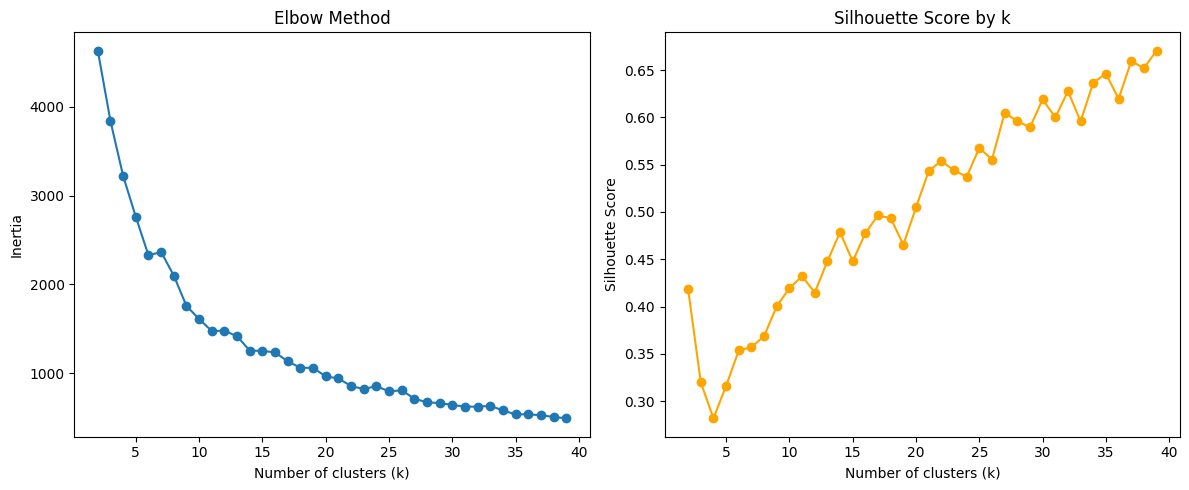

In [26]:
import matplotlib.pyplot as plt

k_range = r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, iners, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, sil_scores, marker="o", color="orange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

In [27]:
for x in range(1,20):
    k_best = KMeans(n_clusters=x)
    clusters = k_best.fit_predict(age_df[features])
    age_df["cluster"] = clusters

    age_stats = age_df.groupby("cluster")["Age"].agg(["mean", "std", "var", "count"])
    print(age_stats)

                 mean       std       var  count
cluster                                         
0        1.090056e-16  1.000478  1.000957   1046
             mean       std       var  count
cluster                                     
0       -0.300139  0.871600  0.759686    678
1        0.552974  0.987785  0.975719    368
             mean       std       var  count
cluster                                     
0       -0.866383  1.088215  1.184211    160
1       -0.085381  0.767690  0.589348    594
2        0.648416  0.947104  0.897005    292
             mean       std       var  count
cluster                                     
0       -0.261417  0.761158  0.579362    442
1        0.480842  0.988342  0.976820    154
2        0.293763  1.024460  1.049518    373
3       -0.884116  1.102857  1.216294     77
             mean       std       var  count
cluster                                     
0        0.649398  0.916864  0.840640    321
1       -0.091747  0.729306  0.531887    53

In [28]:
k_best = KMeans(n_clusters=11)
clusters = k_best.fit_predict(age_df[features])
age_df["cluster"] = clusters

In [29]:
cluster_means = age_df.groupby("cluster")["Age"].transform("mean")
age_df["Age"] = age_df["Age"].fillna(cluster_means)

In [30]:
cluster_means

0     -0.075069
1      0.731914
2     -0.500256
3      0.675970
4     -0.075069
         ...   
413   -0.075069
414    0.731914
415   -0.075069
416   -0.075069
417   -0.500256
Name: Age, Length: 1309, dtype: float64

In [31]:
age_df["Age"].isna().sum()

np.int64(0)

In [32]:
age_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
train_col         0
Title             0
Cabin_Title       0
cluster           0
dtype: int64

In [33]:
age_df.shape

(1309, 16)

In [34]:
age_df.Cabin.isna().sum()

np.int64(1014)

In [35]:
cabin_con = age_df.Cabin.isna()
cabin_na_df = age_df[cabin_con]
cabin_df = age_df[~cabin_con]

In [36]:
cabin_na_df.isna().sum()

PassengerId       0
Survived        327
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
train_col         0
Title             0
Cabin_Title       0
cluster           0
dtype: int64

In [37]:
cabin_df.isna().sum()

PassengerId     0
Survived       91
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin           0
Embarked        0
train_col       0
Title           0
Cabin_Title     0
cluster         0
dtype: int64

In [38]:
cabin_df.Cabin.value_counts()

Cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F33                4
F2                 4
                  ..
C39                1
B24                1
D40                1
D38                1
C105               1
Name: count, Length: 186, dtype: int64

In [43]:
cabin_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title,Cabin_Title,cluster
1,2,1.0,-1.546098,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.0,0.563552,0.481288,-0.445000,816.0,0.734744,C,0.0,1,3.0,2.0,2
3,4,1.0,-1.546098,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,0.355314,0.481288,-0.445000,65.0,0.383183,C,2.0,1,3.0,2.0,6
6,7,0.0,-1.546098,"McCarthy, Mr. Timothy J",1.0,1.674153,-0.479087,-0.445000,109.0,0.359257,E,2.0,1,2.0,4.0,4
10,11,1.0,0.841916,"Sandstrom, Miss. Marguerite Rut",0.0,-1.796478,0.481288,0.710763,839.0,-0.320583,G,2.0,1,1.0,6.0,8
11,12,1.0,-1.546098,"Bonnell, Miss. Elizabeth",0.0,1.951804,-0.479087,-0.445000,50.0,-0.130140,C,2.0,1,1.0,2.0,4


In [47]:
cabin_df = age_df[~cabin_con].copy()
cabin_df["Cabin"] = cabin_df["Cabin"].str[0]       

feature_cols = ["Pclass", "Sex", "Age", "SibSp", "Parch",
                "Fare", "Embarked", "Title", "Ticket", "cluster"]

X_train = cabin_df[feature_cols]      
y_train = cabin_df["Cabin"]

In [46]:
cabin_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_col,Title,Cabin_Title,cluster
1,2,1.0,-1.546098,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.0,0.563552,0.481288,-0.445000,816.0,0.734744,C,0.0,1,3.0,2.0,2
3,4,1.0,-1.546098,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,0.355314,0.481288,-0.445000,65.0,0.383183,C,2.0,1,3.0,2.0,6
6,7,0.0,-1.546098,"McCarthy, Mr. Timothy J",1.0,1.674153,-0.479087,-0.445000,109.0,0.359257,E,2.0,1,2.0,4.0,4
10,11,1.0,0.841916,"Sandstrom, Miss. Marguerite Rut",0.0,-1.796478,0.481288,0.710763,839.0,-0.320583,G,2.0,1,1.0,6.0,8
11,12,1.0,-1.546098,"Bonnell, Miss. Elizabeth",0.0,1.951804,-0.479087,-0.445000,50.0,-0.130140,C,2.0,1,1.0,2.0,4


In [50]:
X_train.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Ticket,cluster
1,-1.546098,0.0,0.563552,0.481288,-0.445000,0.734744,0.0,3.0,816.0,2
3,-1.546098,0.0,0.355314,0.481288,-0.445000,0.383183,2.0,3.0,65.0,6
6,-1.546098,1.0,1.674153,-0.479087,-0.445000,0.359257,2.0,2.0,109.0,4
10,0.841916,0.0,-1.796478,0.481288,0.710763,-0.320583,2.0,1.0,839.0,8
11,-1.546098,0.0,1.951804,-0.479087,-0.445000,-0.130140,2.0,1.0,50.0,4


In [51]:
X_train.shape

(295, 10)

In [48]:
na_cabin_df = age_df[cabin_con].copy()

X_test = na_cabin_df[feature_cols]
y_test = na_cabin_df["Cabin"]

In [49]:
X_test.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Ticket,cluster
0,0.841916,1.0,-0.547050,0.481288,-0.445000,-0.503291,2.0,2.0,720.0,1
2,0.841916,0.0,-0.269400,-0.479087,-0.445000,-0.490240,2.0,1.0,914.0,0
4,0.841916,1.0,0.355314,-0.479087,-0.445000,-0.487824,2.0,2.0,649.0,1
5,0.841916,1.0,-0.075069,-0.479087,-0.445000,-0.479930,1.0,2.0,373.0,1
7,0.841916,1.0,-1.935303,2.402037,0.710763,-0.235995,2.0,0.0,541.0,5


In [52]:
from xgboost import XGBClassifier

In [53]:
xgb_class = XGBClassifier()
xgb_class.fit(X_train,y_train)

In [55]:
merged_df.groupby(merged_df.Cabin.isna())["Pclass"].value_counts()

Cabin  Pclass
False  1         256
       2          23
       3          16
True   3         693
       2         254
       1          67
Name: count, dtype: int64

In [56]:
deck_map = {"A":"ABC", "B":"ABC", "C":"ABC", "T":"ABC",
            "D":"DE",  "E":"DE",
            "F":"FG",  "G":"FG",
            "Unknown":"Unknown"}
age_df["Deck"] = merged_df["Cabin_Title"].map(deck_map).values

In [57]:
age_df["TicketGroup"] = merged_df.groupby("Ticket")["Ticket"].transform("count").values

In [58]:
age_df["FamilySize"] = age_df["SibSp"] + age_df["Parch"] + 1
age_df["IsAlone"]    = (age_df["FamilySize"] == 1).astype(int)
age_df["FarePerHead"] = merged_df["Fare"].values / age_df["TicketGroup"]